# Restaurant Daily Revenue — Forecasting

**Author:** *Sanan * · **Last updated:** 2026

---

## Problem

A small multi-city restaurant group wants to forecast **daily total revenue** for the coming week so managers can schedule staff and order inventory. Getting the forecast wrong is expensive in both directions — overstaffing cuts margin, understaffing loses sales and damages reviews.

## Goal

Build a **7-day-ahead daily revenue forecast** with prediction intervals, evaluated against strong baselines using time-aware cross-validation.

## Approach

1. **Aggregate** transaction-level records into a daily revenue series.
2. **Explore** trend, weekly seasonality, and structural segments (product, city).
3. **Benchmark** against naive and seasonal-naive baselines — any proposed model must beat these to earn its complexity.
4. **Engineer** calendar and lag features, then fit a linear (Ridge) and a non-linear (Gradient Boosting) model.
5. **Evaluate** with rolling-origin cross-validation on MAE / RMSE / MAPE.
6. **Forecast** the next 7 days with 90% prediction intervals via quantile regression.

## Dataset

| Attribute | Value |
|---|---|
| Rows | 255 transaction records |
| Date range | ~53 consecutive days |
| Granularity | Daily, aggregated from 3–7 records per day |
| Cities | 5 (London, Madrid, Lisbon, Berlin, Paris) |
| Products | 5 categories |

> Small sample size is the central modeling constraint. This rules out long-horizon models (SARIMA with yearly seasonality, LSTMs). It favors models with strong inductive biases: seasonal-naive, Ridge with engineered features, and shallow gradient boosting.


## 0 · Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit

# Plotting defaults
plt.rcParams.update({
    "figure.figsize": (11, 4.5),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "font.size": 10,
})

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1 · Data loading and validation

Load the raw file, coerce types, and run a set of sanity checks. Any failure here invalidates downstream analysis.

In [2]:
raw = pd.read_csv("~/salesr.csv")
print(f"Shape: {raw.shape}")
raw.head()


Shape: (254, 9)


,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City
0,10452,07-11-2022,Fries,3.49,573.07,Online,Gift Card,Tom Jackson,London
1,10453,07-11-2022,Beverages,2.95,745.76,Online,Gift Card,Pablo Perez,Madrid
2,10454,07-11-2022,Sides & Other,4.99,200.40,In-store,Gift Card,Joao Silva,Lisbon
3,10455,08-11-2022,Burgers,12.99,569.67,In-store,Credit Card,Walter Muller,Berlin
4,10456,08-11-2022,Chicken Sandwiches,9.95,201.01,In-store,Credit Card,Walter Muller,Berlin


In [3]:
df = raw.copy()
df.columns = df.columns.str.strip()
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
df["Manager"] = df["Manager"].str.strip()

checks = {
    "Missing values (any column)": int(df.isna().sum().sum()),
    "Duplicate Order IDs": int(df["Order ID"].duplicated().sum()),
    "Rows with non-positive Price": int((df["Price"] <= 0).sum()),
    "Rows with non-positive Quantity": int((df["Quantity"] <= 0).sum()),
    "Unparseable dates": int(df["Date"].isna().sum()),
}
pd.Series(checks, name="count").to_frame()

,count
Missing values (any column),0
Duplicate Order IDs,0
Rows with non-positive Price,0
Rows with non-positive Quantity,0
Unparseable dates,0


In [5]:
min_d, max_d = df["Date"].min(), df["Date"].max()
full_range = pd.date_range(min_d, max_d, freq="D")
missing_days = full_range.difference(df["Date"].unique())

print(f"Date range: {min_d.date()} - {max_d.date()}  ({len(full_range)} calendar days)")
print(f"Unique days with records: {df['Date'].nunique()}")
print(f"Missing calendar days: {len(missing_days)}")
if len(missing_days):
    print("  - e.g.", list(missing_days[:5]))


Date range: 2022-11-07 - 2022-12-29  (53 calendar days)
Unique days with records: 53
Missing calendar days: 0


## 2 · Aggregate to daily revenue

The target is **daily total revenue** = SUM (Price × Quantity) per day. Transaction-level rows carry useful segment information but are not what we forecast.

If any calendar days are missing from the data, we assume they're closed-business days and fill with 0 — which the models can then pick up as weekly pattern rather than noise. This is a design decision and should be revisited if metadata on closures is available.

In [7]:
df["Revenue"] = df["Price"] * df["Quantity"]

daily = (df.groupby("Date", as_index=False)["Revenue"].sum()
      .set_index("Date")
      .reindex(pd.date_range(df["Date"].min(), df["Date"].max(), freq="D"), fill_value=0.0)
      .rename_axis("Date"))

daily.columns = ["revenue"]
daily["dow"] = daily.index.dayofweek           # 0=Mon ... 6=Sun
daily["dow_name"] = daily.index.day_name()

print(f"Daily series: {len(daily)} days, "
      f"mean = {daily['revenue'].mean():,.0f}, "
      f"std = {daily['revenue'].std():,.0f}")
daily.head()

Daily series: 53 days, mean = 14,519, std = 2,822


,revenue,dow,dow_name
Date,,,
2022-11-07,5200.0023,0,Monday
2022-11-08,12400.0731,1,Tuesday
2022-11-09,14200.0386,2,Wednesday
2022-11-10,13200.0426,3,Thursday
2022-11-11,14400.0156,4,Friday


## 3 · Exploratory data analysis

Three questions drive this section:

1. **Is there a trend?** Determines whether differencing or detrending is needed.
2. **Is there weekly seasonality, and how strong?** Sets the floor for any decent baseline.
3. **Are there obvious anomalies or level shifts?** Flag them before they leak into training.

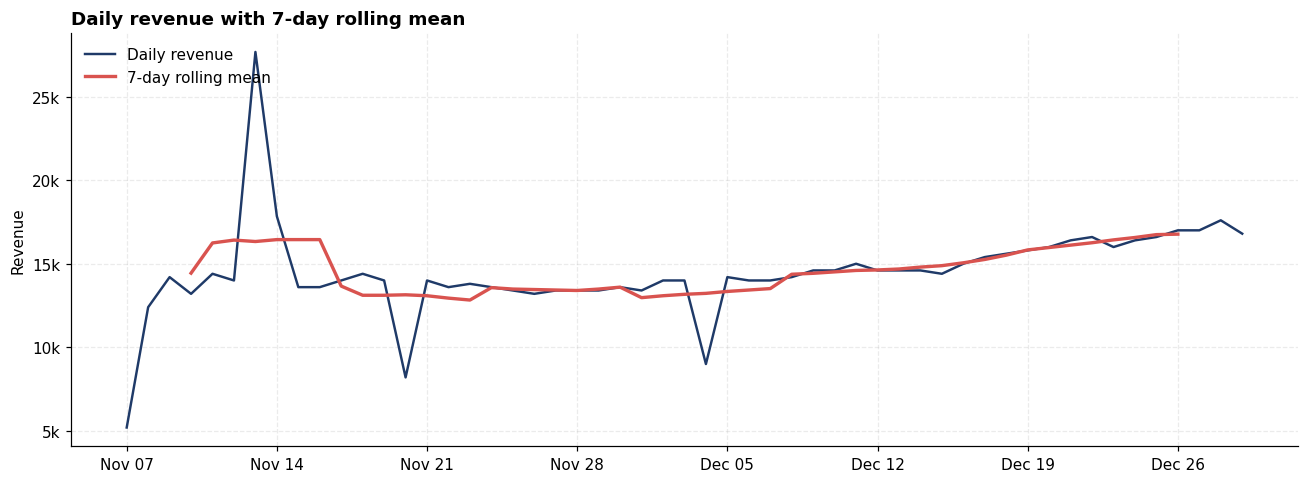

In [8]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(daily.index, daily["revenue"], color="#1f3a68", linewidth=1.6, label="Daily revenue")
ax.plot(daily.index, daily["revenue"].rolling(7, center=True).mean(),
        color="#d9534f", linewidth=2.2, label="7-day rolling mean")
ax.set_title("Daily revenue with 7-day rolling mean", loc="left", fontweight="bold")
ax.set_ylabel("Revenue")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.legend(loc="upper left", frameon=False)
plt.tight_layout(); plt.show()

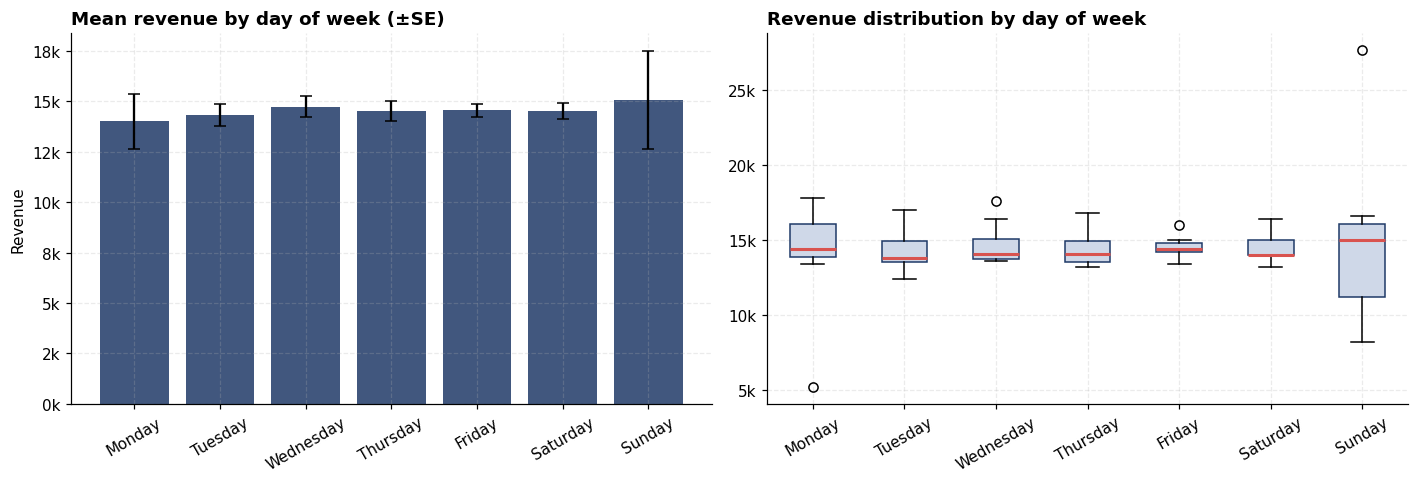

Busiest day is 1.08x the slowest — strong weekly signal


In [10]:
# --- Weekly seasonality --------------------------------------------
dow_stats = (
    daily.groupby("dow_name")["revenue"]
         .agg(["mean", "std", "count"])
         .reindex(["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

bars = ax1.bar(dow_stats.index, dow_stats["mean"],
               yerr=dow_stats["std"]/np.sqrt(dow_stats["count"]),
               color="#1f3a68", alpha=0.85, capsize=4)
ax1.set_title("Mean revenue by day of week (±SE)", loc="left", fontweight="bold")
ax1.set_ylabel("Revenue")
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
ax1.tick_params(axis="x", rotation=30)

box_data = [daily.loc[daily["dow_name"] == d, "revenue"].values
            for d in dow_stats.index]
ax2.boxplot(box_data, labels=dow_stats.index, patch_artist=True,
            boxprops=dict(facecolor="#cfd8e8", edgecolor="#1f3a68"),
            medianprops=dict(color="#d9534f", linewidth=2))
ax2.set_title("Revenue distribution by day of week", loc="left", fontweight="bold")
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
ax2.tick_params(axis="x", rotation=30)

plt.tight_layout(); plt.show()

# Quantify: ratio of busiest to slowest day
ratio = dow_stats["mean"].max() / dow_stats["mean"].min()
print(f"Busiest day is {ratio:.2f}x the slowest — strong weekly signal")


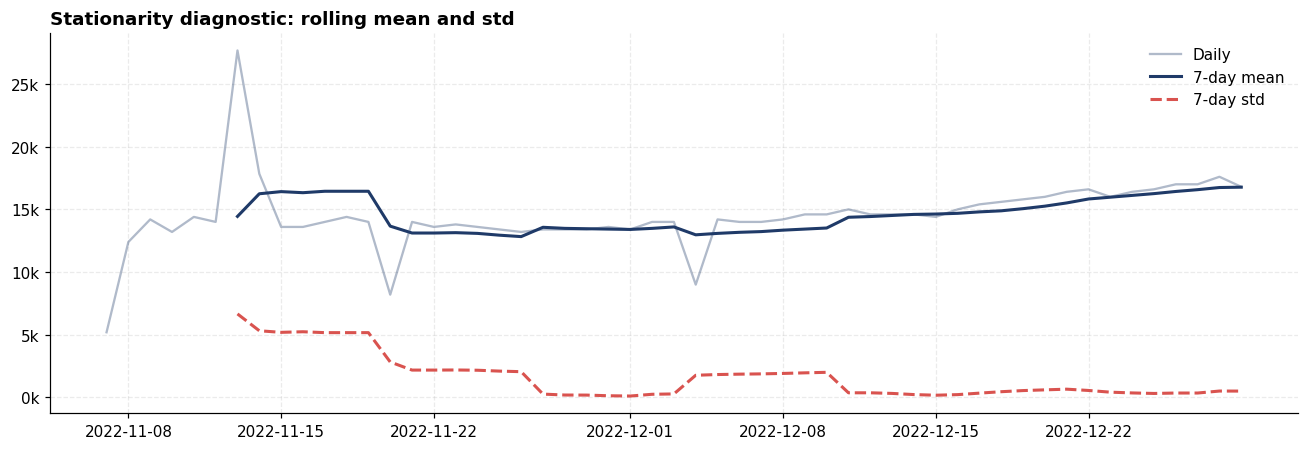

First-half mean : 13,827
Second-half mean: 15,185   (∆ = +9.8%)


In [11]:
# --- Stationarity check 
window = 7
rolling_mean = daily["revenue"].rolling(window).mean()
rolling_std  = daily["revenue"].rolling(window).std()

fig, ax = plt.subplots(figsize=(12, 4.2))
ax.plot(daily.index, daily["revenue"], alpha=0.35, color="#1f3a68", label="Daily")
ax.plot(rolling_mean.index, rolling_mean, color="#1f3a68", linewidth=2, label=f"{window}-day mean")
ax.plot(rolling_std.index, rolling_std, color="#d9534f", linewidth=2, linestyle="--", label=f"{window}-day std")
ax.set_title("Stationarity diagnostic: rolling mean and std", loc="left", fontweight="bold")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
ax.legend(frameon=False); plt.tight_layout(); plt.show()

# First-half vs second-half mean — quick check for level shift / drift
h = len(daily) // 2
m1, m2 = daily["revenue"].iloc[:h].mean(), daily["revenue"].iloc[h:].mean()
print(f"First-half mean : {m1:,.0f}")
print(f"Second-half mean: {m2:,.0f}   (∆ = {(m2-m1)/m1*100:+.1f}%)")

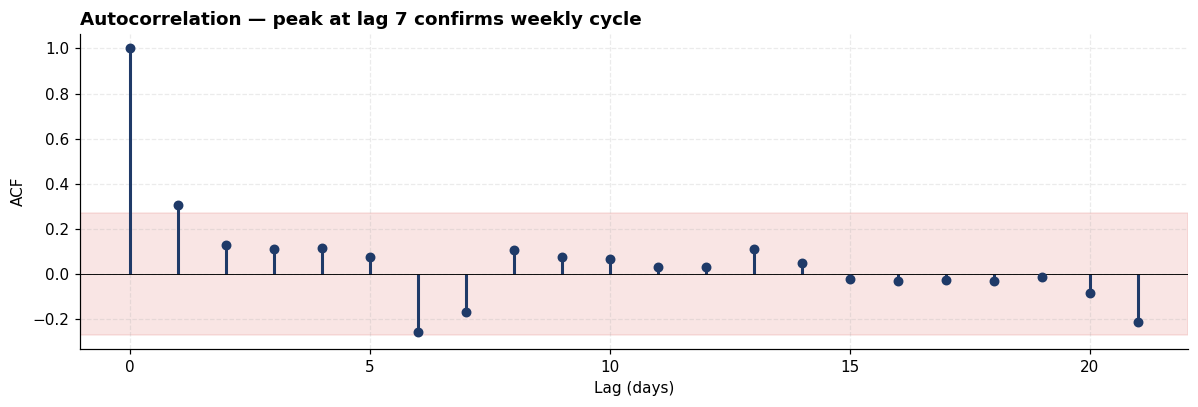

ACF at lag 1 : +0.305
ACF at lag 7 : -0.170   - weekly seasonality
ACF at lag 14: +0.050


In [12]:
# --- Autocorrelation at key lags
def acf_manual(x, nlags=21):
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    denom = np.dot(x, x)
    return np.array([np.dot(x[:len(x)-k], x[k:]) / denom for k in range(nlags + 1)])

ac = acf_manual(daily["revenue"].values, nlags=21)
conf = 1.96 / np.sqrt(len(daily))  # ~95% white-noise band

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.vlines(range(len(ac)), 0, ac, color="#1f3a68", linewidth=2)
ax.scatter(range(len(ac)), ac, color="#1f3a68", zorder=3, s=30)
ax.axhspan(-conf, conf, color="#d9534f", alpha=0.15)
ax.axhline(0, color="k", linewidth=0.6)
ax.set_title("Autocorrelation — peak at lag 7 confirms weekly cycle", loc="left", fontweight="bold")
ax.set_xlabel("Lag (days)"); ax.set_ylabel("ACF")
plt.tight_layout(); plt.show()

print(f"ACF at lag 1 : {ac[1]:+.3f}")
print(f"ACF at lag 7 : {ac[7]:+.3f}   - weekly seasonality")
print(f"ACF at lag 14: {ac[14]:+.3f}")


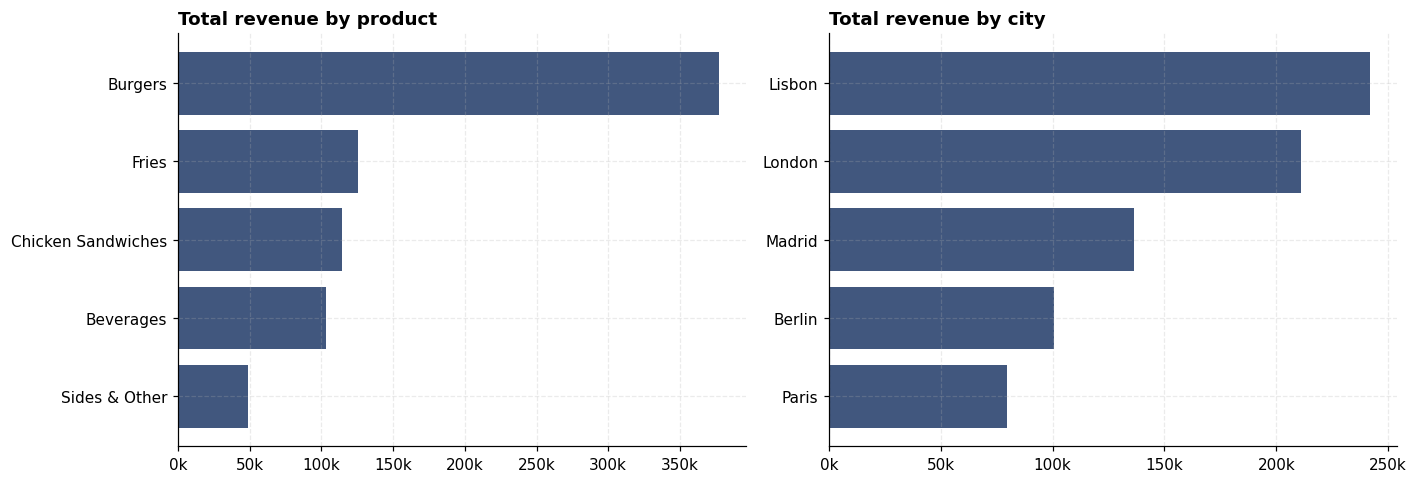

In [13]:
# Where does revenue come from?
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

prod_rev = df.groupby("Product")["Revenue"].sum().sort_values(ascending=True)
axes[0].barh(prod_rev.index, prod_rev.values, color="#1f3a68", alpha=0.85)
axes[0].set_title("Total revenue by product", loc="left", fontweight="bold")
axes[0].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))

city_rev = df.groupby("City")["Revenue"].sum().sort_values(ascending=True)
axes[1].barh(city_rev.index, city_rev.values, color="#1f3a68", alpha=0.85)
axes[1].set_title("Total revenue by city", loc="left", fontweight="bold")
axes[1].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))

plt.tight_layout(); plt.show()


## 4 · Feature engineering

Two families of features, chosen deliberately given 53 observations:

- **Calendar**: `dow` (one-hot), `day_of_month`, `is_weekend`. These encode the weekly and intra-month patterns without eating degrees of freedom.
- **Lags**: `lag_1`, `lag_7`, `rolling_mean_7`. `lag_7` is the single most important feature for this problem and the one that explicitly encodes weekly seasonality.

Polynomial trend and holiday flags are deliberately **omitted** — not enough data to estimate them reliably.

In [14]:
def build_features(series: pd.Series) -> pd.DataFrame:
    X = pd.DataFrame(index=series.index)
    X["revenue"] = series.values
    
    idx = series.index
    X["dow"] = idx.dayofweek
    X["day_of_month"] = idx.day
    X["is_weekend"] = (idx.dayofweek >= 5).astype(int)
    # One-hot dow (n-1 Monday)
    dow_dummies = pd.get_dummies(X["dow"], prefix="dow").iloc[:, 1:].astype(int)
    X = pd.concat([X, dow_dummies], axis=1)
    X = X.drop(columns=["dow"])

    # Lags
    X["lag_1"] = X["revenue"].shift(1)
    X["lag_7"] = X["revenue"].shift(7)
    X["rolling_mean_7"] = X["revenue"].shift(1).rolling(7).mean()

    return X

features = build_features(daily["revenue"]).dropna()
target_col = "revenue"

print(f"After dropping rows with incomplete lags: {len(features)} usable days")
features.head()


After dropping rows with incomplete lags: 46 usable days


,revenue,day_of_month,is_weekend,dow_1,dow_2,dow_3,dow_4,dow_5,dow_6,lag_1,lag_7,rolling_mean_7
Date,,,,,,,,,,,,
2022-11-14,17839.3445,14,0,0,0,0,0,0,0,27674.4512,5200.0023,14439.239557
2022-11-15,13600.0305,15,0,1,0,0,0,0,0,17839.3445,12400.0731,16244.859871
2022-11-16,13600.0305,16,0,0,1,0,0,0,0,13600.0305,14200.0386,16416.282357
2022-11-17,14000.0535,17,0,0,0,1,0,0,0,13600.0305,13200.0426,16330.566914
2022-11-18,14400.1114,18,0,0,0,0,1,0,0,14000.0535,14400.0156,16444.854186


## 5 · Train / test split

**Time-ordered**, no shuffling. The final 14 days are held out entirely. 14 days covers exactly two weekly cycles, which is the minimum needed to fairly evaluate a seasonal model.

In [15]:
TEST_DAYS = 14
train = features.iloc[:-TEST_DAYS].copy()
test  = features.iloc[-TEST_DAYS:].copy()

feature_cols = [c for c in features.columns if c != target_col]
X_train, y_train = train[feature_cols], train[target_col]
X_test,  y_test  = test[feature_cols],  test[target_col]

print(f"Train: {train.index.min().date()} - {train.index.max().date()}  ({len(train)} days)")
print(f"Test : {test.index.min().date()} - {test.index.max().date()}  ({len(test)} days)")


Train: 2022-11-14 - 2022-12-15  (32 days)
Test : 2022-12-16 - 2022-12-29  (14 days)


## 6 · Evaluation metrics

Three metrics, each answering a different question:

- **MAE** — the number the business cares about: average error in currency units.
- **RMSE** — penalises big misses more; catches models that occasionally blow up.
- **MAPE** — scale-free, lets us compare across days or against other projects.

In [16]:
def mae(y_true, y_pred):  return float(np.mean(np.abs(y_true - y_pred)))
def rmse(y_true, y_pred): return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
def mape(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    mask = y_true != 0
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)

def score(y_true, y_pred, name: str) -> dict:
    return {"model": name, "MAE": mae(y_true, y_pred),
            "RMSE": rmse(y_true, y_pred), "MAPE_%": mape(y_true, y_pred)}


## 7 · Baselines

**Rule**: no model ships unless it beats these.

- **Naive**: tomorrow = today.
- **Seasonal naive**: tomorrow = same day last week. For weekly-seasonal data this is often shockingly hard to beat.
- **Moving-average (7)**: tomorrow = mean of the last 7 days. Smooths out the weekly pattern — expected to underperform seasonal-naive here.

In [17]:
full = daily["revenue"]
h_start, h_end = test.index.min(), test.index.max()

# Naive: previous day's value
naive = full.shift(1).loc[h_start:h_end]

# Seasonal naive: same day last week
snaive = full.shift(7).loc[h_start:h_end]

# Moving average of previous 7 days
ma7 = full.shift(1).rolling(7).mean().loc[h_start:h_end]

baseline_scores = pd.DataFrame([
    score(y_test, naive,  "Naive (lag-1)"),
    score(y_test, snaive, "Seasonal Naive (lag-7)"),
    score(y_test, ma7,    "Moving Avg (7)"),
])
baseline_scores.round(2)


,model,MAE,RMSE,MAPE_%
0,Naive (lag-1),371.4,427.59,2.28
1,Seasonal Naive (lag-7),1071.4,1181.97,6.54
2,Moving Avg (7),675.5,750.52,4.14


## 8 · Model 1 — Ridge regression

Linear, regularised, interpretable. Ridge is a natural first real model when features are engineered well: it gets most of the signal and its coefficients are readable.

In [18]:
ridge_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge",  Ridge(alpha=1.0, random_state=RANDOM_STATE)),
])
ridge_pipe.fit(X_train, y_train)
ridge_pred = ridge_pipe.predict(X_test)

ridge_score = score(y_test, ridge_pred, "Ridge")
ridge_score


{'model': 'Ridge',
 'MAE': 2829.400968480187,
 'RMSE': 3047.960041665017,
 'MAPE_%': 17.203612716873245}

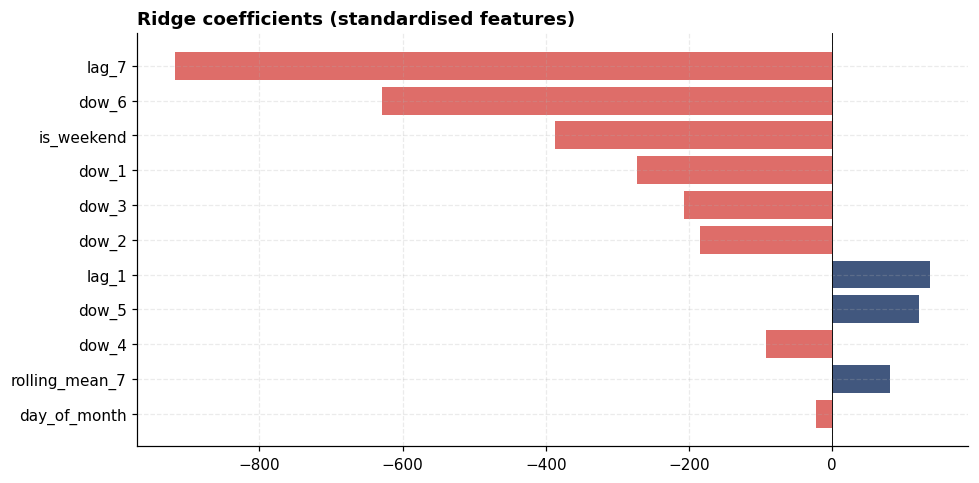

In [19]:
# Coefficient inspection — which features does Ridge actually use?
coefs = pd.Series(ridge_pipe.named_steps["ridge"].coef_, index=feature_cols)
coefs_sorted = coefs.reindex(coefs.abs().sort_values(ascending=True).index)

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ["#d9534f" if c < 0 else "#1f3a68" for c in coefs_sorted.values]
ax.barh(coefs_sorted.index, coefs_sorted.values, color=colors, alpha=0.85)
ax.axvline(0, color="k", linewidth=0.6)
ax.set_title("Ridge coefficients (standardised features)", loc="left", fontweight="bold")
plt.tight_layout(); plt.show()


## 9 · Model 2 — Gradient Boosting

Captures non-linearities and feature interactions Ridge can't, at the cost of interpretability. Kept intentionally shallow (`max_depth=3`, `n_estimators=200`) because the dataset is small and overfitting is the main risk.

In [20]:
gbr = GradientBoostingRegressor(
    n_estimators=200, max_depth=3, learning_rate=0.05,
    subsample=0.8, random_state=RANDOM_STATE,
)
gbr.fit(X_train, y_train)
gbr_pred = gbr.predict(X_test)

gbr_score = score(y_test, gbr_pred, "Gradient Boosting")
gbr_score


{'model': 'Gradient Boosting',
 'MAE': 2669.4520998609555,
 'RMSE': 2984.915817590588,
 'MAPE_%': 16.1731541177301}

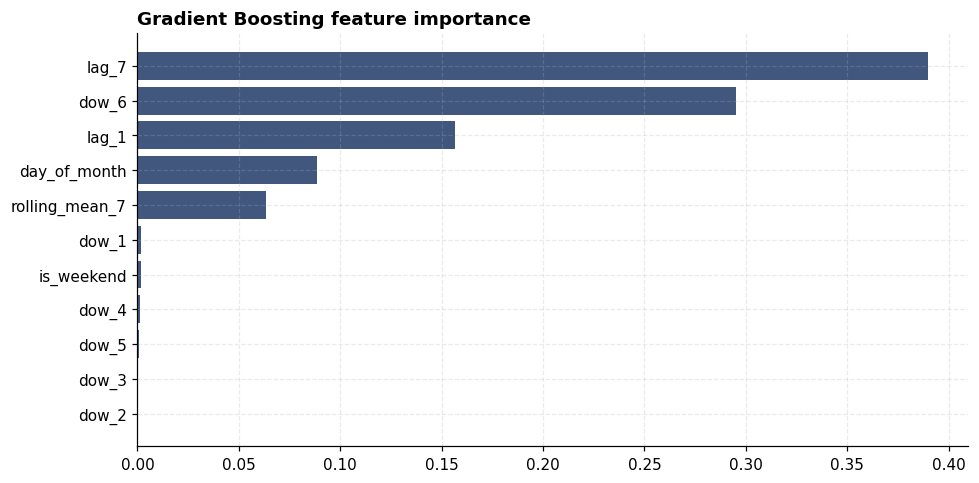

In [21]:
imp = pd.Series(gbr.feature_importances_, index=feature_cols).sort_values()
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(imp.index, imp.values, color="#1f3a68", alpha=0.85)
ax.set_title("Gradient Boosting feature importance", loc="left", fontweight="bold")
plt.tight_layout(); plt.show()


## 10 · Rolling-origin cross-validation

A single train/test split is high-variance — with 14 test days, one weird weekend swings the numbers. Rolling-origin CV gives a more honest estimate of out-of-sample performance by averaging across multiple splits, always respecting time order.

In [22]:
def rolling_cv(model_factory, X, y, n_splits=4):
    """Time-ordered CV. Each fold trains on everything before the test window."""
    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=7)
    maes, rmses, mapes = [], [], []
    for train_idx, test_idx in tscv.split(X):
        Xtr, Xte = X.iloc[train_idx], X.iloc[test_idx]
        ytr, yte = y.iloc[train_idx], y.iloc[test_idx]
        m = model_factory()
        m.fit(Xtr, ytr)
        pred = m.predict(Xte)
        maes.append(mae(yte, pred)); rmses.append(rmse(yte, pred)); mapes.append(mape(yte, pred))
    return {"MAE": np.mean(maes), "RMSE": np.mean(rmses), "MAPE_%": np.mean(mapes),
            "MAE_std": np.std(maes)}

X_all, y_all = features[feature_cols], features[target_col]

cv_ridge = rolling_cv(lambda: Pipeline([("s", StandardScaler()),
                                         ("r", Ridge(alpha=1.0, random_state=RANDOM_STATE))]),
                      X_all, y_all)
cv_gbr   = rolling_cv(lambda: GradientBoostingRegressor(
                          n_estimators=200, max_depth=3, learning_rate=0.05,
                          subsample=0.8, random_state=RANDOM_STATE),
                      X_all, y_all)

cv_df = pd.DataFrame({
    "Ridge (CV)": cv_ridge,
    "Gradient Boosting (CV)": cv_gbr,
}).T
cv_df.round(2)


,MAE,RMSE,MAPE_%,MAE_std
Ridge (CV),1576.35,1874.12,10.44,713.26
Gradient Boosting (CV),1432.84,1789.06,9.75,325.36


## 11 · Model comparison

All candidates together, sorted by MAE on the holdout. The column to read first is **MAE** — it's in the same units as revenue.

In [23]:
leaderboard = pd.concat([
    baseline_scores,
    pd.DataFrame([ridge_score, gbr_score]),
], ignore_index=True).sort_values("MAE").reset_index(drop=True)

leaderboard_display = leaderboard.copy()
for c in ["MAE", "RMSE", "MAPE_%"]:
    leaderboard_display[c] = leaderboard_display[c].round(2)
leaderboard_display


,model,MAE,RMSE,MAPE_%
0,Naive (lag-1),371.40,427.59,2.28
1,Moving Avg (7),675.50,750.52,4.14
2,Seasonal Naive (lag-7),1071.40,1181.97,6.54
3,Gradient Boosting,2669.45,2984.92,16.17
4,Ridge,2829.40,3047.96,17.20


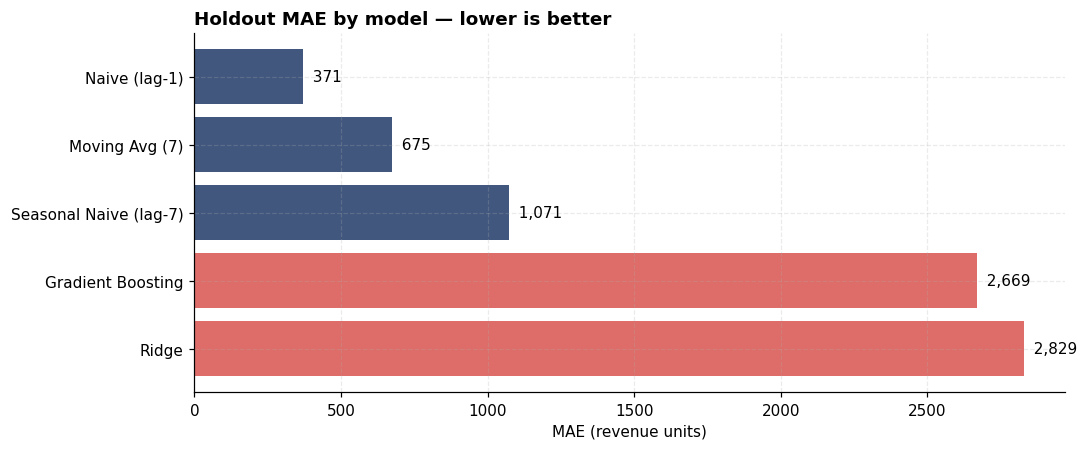

In [24]:
fig, ax = plt.subplots(figsize=(10, 4.2))
y_pos = np.arange(len(leaderboard))
colors = ["#1f3a68" if "Naive" in m or "Moving" in m else "#d9534f"
          for m in leaderboard["model"]]
ax.barh(y_pos, leaderboard["MAE"], color=colors, alpha=0.85)
ax.set_yticks(y_pos); ax.set_yticklabels(leaderboard["model"])
ax.invert_yaxis()
ax.set_xlabel("MAE (revenue units)")
ax.set_title("Holdout MAE by model — lower is better", loc="left", fontweight="bold")
for i, v in enumerate(leaderboard["MAE"]):
    ax.text(v, i, f"  {v:,.0f}", va="center")
plt.tight_layout(); plt.show()


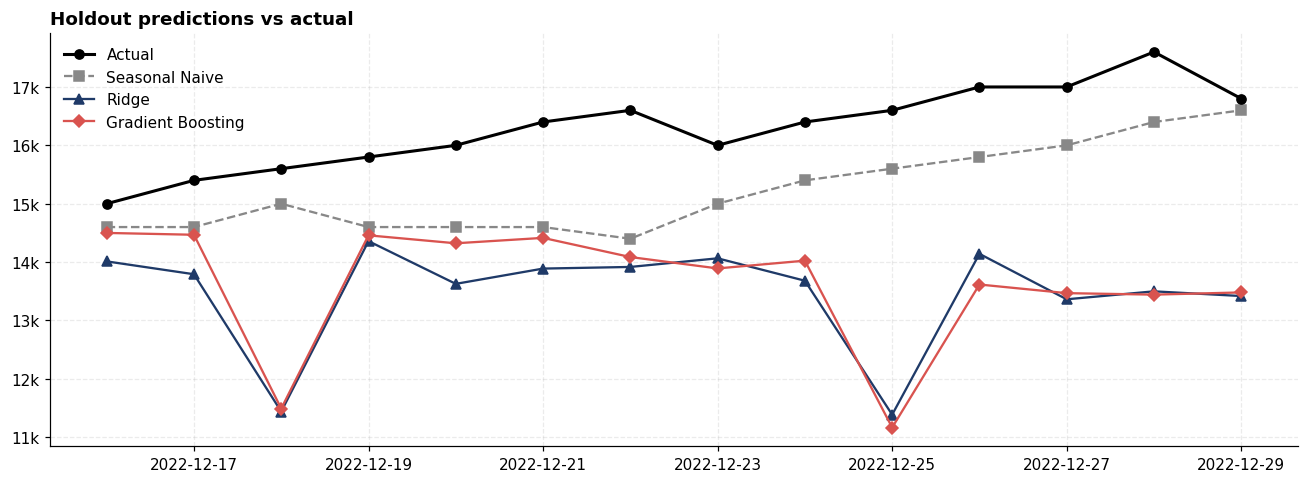

In [25]:
# Visual comparison of pred. vs actual on the holdout
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(y_test.index, y_test.values, marker="o", color="black",
        linewidth=2, label="Actual", zorder=5)
ax.plot(y_test.index, snaive.values, marker="s", linestyle="--",
        color="#888", label="Seasonal Naive")
ax.plot(y_test.index, ridge_pred, marker="^", color="#1f3a68", label="Ridge")
ax.plot(y_test.index, gbr_pred, marker="D", color="#d9534f", label="Gradient Boosting")
ax.set_title("Holdout predictions vs actual", loc="left", fontweight="bold")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
ax.legend(frameon=False); plt.tight_layout(); plt.show()

## 12 · Residual diagnostics

If residuals show structure, the model is leaving signal on the table. We want: roughly centred at zero, no obvious pattern over time, no strong autocorrelation.

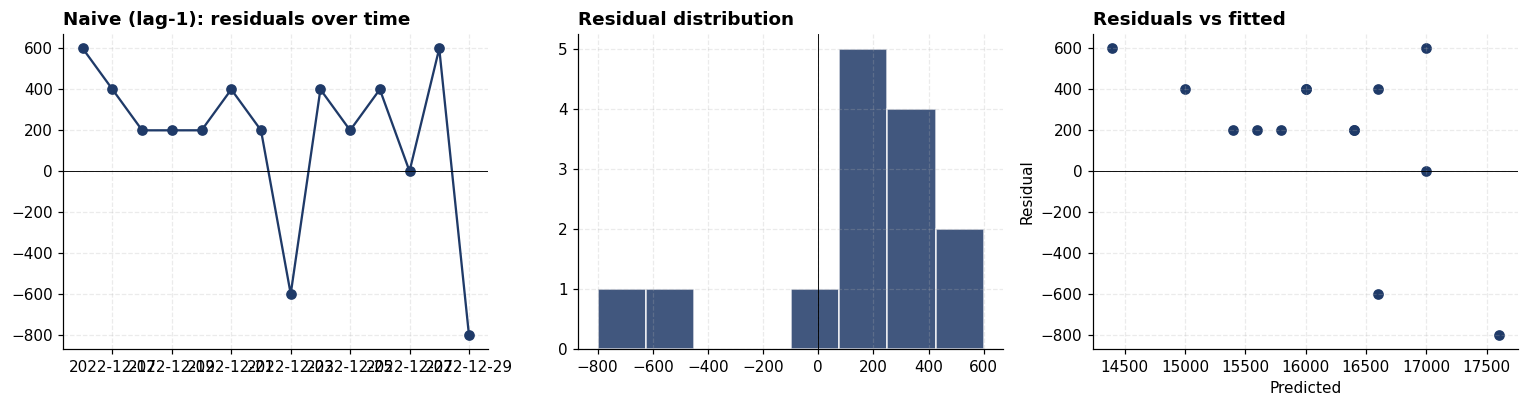

Mean residual: +171  (a non-zero mean suggests systematic bias)


In [26]:
best_name = leaderboard.iloc[0]["model"]
best_pred = {"Ridge": ridge_pred, "Gradient Boosting": gbr_pred,
             "Seasonal Naive (lag-7)": snaive.values,
             "Naive (lag-1)": naive.values,
             "Moving Avg (7)": ma7.values}[best_name]
residuals = y_test.values - np.asarray(best_pred)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))

axes[0].plot(y_test.index, residuals, marker="o", color="#1f3a68")
axes[0].axhline(0, color="k", linewidth=0.6)
axes[0].set_title(f"{best_name}: residuals over time", loc="left", fontweight="bold")

axes[1].hist(residuals, bins=8, color="#1f3a68", alpha=0.85, edgecolor="white")
axes[1].axvline(0, color="k", linewidth=0.6)
axes[1].set_title("Residual distribution", loc="left", fontweight="bold")

axes[2].scatter(best_pred, residuals, color="#1f3a68")
axes[2].axhline(0, color="k", linewidth=0.6)
axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("Residual")
axes[2].set_title("Residuals vs fitted", loc="left", fontweight="bold")

plt.tight_layout(); plt.show()

print(f"Mean residual: {residuals.mean():+,.0f}  "
      f"(a non-zero mean suggests systematic bias)")

## 13 · 7-day forecast with 90% prediction intervals

Refit the best point-forecast model on **all** available data, then train two companion quantile models at α=0.05 and α=0.95 for the interval bands. Forecasts are generated **recursively** — each day's prediction feeds into the lag features for the next.

Intervals matter operationally. "Friday revenue will be €7,400" is useless for ordering; "Friday revenue will be between €6,100 and €8,800 with 90% confidence"

In [27]:
HORIZON = 7

def refit_gbr(loss="squared_error", alpha=None):
    kwargs = dict(n_estimators=200, max_depth=3, learning_rate=0.05,
                  subsample=0.8, random_state=RANDOM_STATE, loss=loss)
    if alpha is not None:
        kwargs["alpha"] = alpha
    m = GradientBoostingRegressor(**kwargs)
    m.fit(X_all, y_all)
    return m

model_point = refit_gbr("squared_error")
model_lo    = refit_gbr("quantile", alpha=0.05)
model_hi    = refit_gbr("quantile", alpha=0.95)

# Recursive forecast: roll the features forward one day at a time
history = daily["revenue"].copy()
future_idx = pd.date_range(history.index[-1] + pd.Timedelta(days=1),
                           periods=HORIZON, freq="D")

forecast = []
for d in future_idx:
    row = {
        "day_of_month": d.day,
        "is_weekend": int(d.dayofweek >= 5),
        **{f"dow_{i}": int(d.dayofweek == i) for i in range(1, 7)},
        "lag_1": history.iloc[-1],
        "lag_7": history.iloc[-7],
        "rolling_mean_7": history.iloc[-7:].mean(),
    }
    x = pd.DataFrame([row])[feature_cols]
    y_hat = float(model_point.predict(x)[0])
    y_lo  = float(model_lo.predict(x)[0])
    y_hi  = float(model_hi.predict(x)[0])
    forecast.append({"date": d, "forecast": y_hat,
                     "lower_90": y_lo, "upper_90": y_hi})
    history.loc[d] = y_hat  # feed back for next iteration

forecast_df = pd.DataFrame(forecast).set_index("date")
forecast_df.round(0)


,forecast,lower_90,upper_90
date,,,
2022-12-30,17105.0,15159.0,17178.0
2022-12-31,17276.0,15237.0,17351.0
2023-01-01,16558.0,11338.0,17229.0
2023-01-02,16286.0,13111.0,16749.0
2023-01-03,15926.0,13333.0,16729.0
2023-01-04,16132.0,13111.0,16594.0
2023-01-05,16339.0,13556.0,16627.0


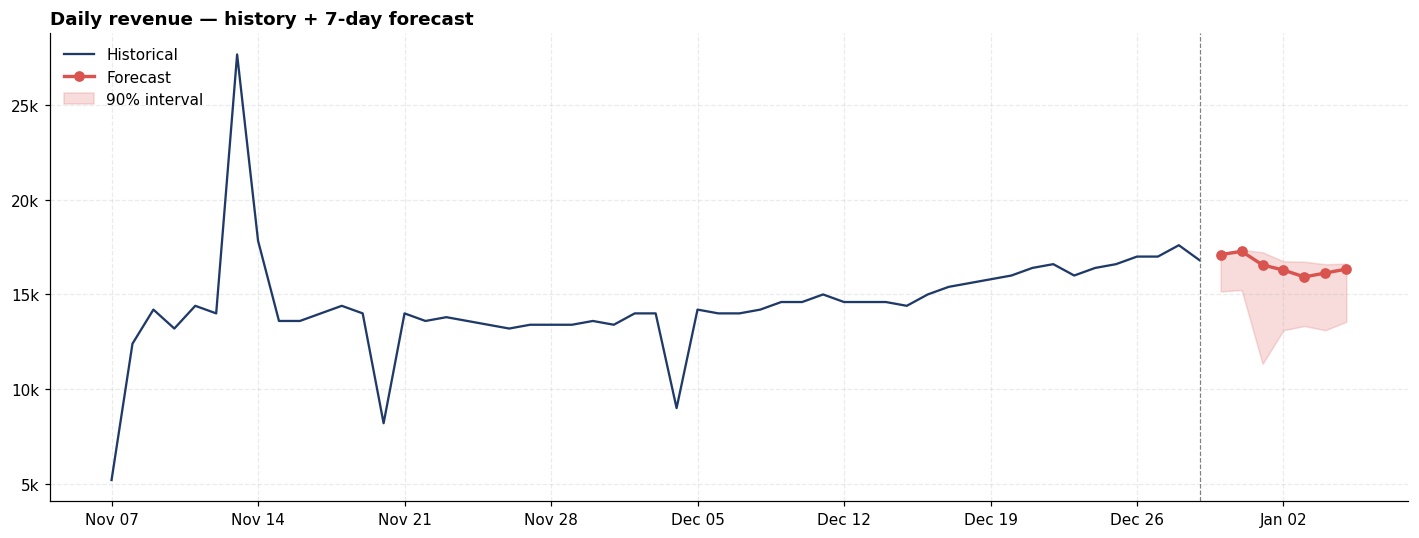

Next 7 days — expected total revenue:    115,622
               90% interval          : [94,844, 118,456]
               busiest day (forecast): Saturday Dec 31  (17,276)
               slowest day (forecast): Tuesday Jan 03  (15,926)


In [29]:
# Visualize the forecast 
fig, ax = plt.subplots(figsize=(13, 5))

# History
ax.plot(daily.index, daily["revenue"], color="#1f3a68", linewidth=1.5, label="Historical")

# Forecast
ax.plot(forecast_df.index, forecast_df["forecast"],
        color="#d9534f", linewidth=2.2, marker="o", label="Forecast")
ax.fill_between(forecast_df.index, forecast_df["lower_90"], forecast_df["upper_90"],
                color="#d9534f", alpha=0.20, label="90% interval")

# Cosmetic
ax.axvline(daily.index[-1], color="gray", linewidth=0.8, linestyle="--")
ax.set_title("Daily revenue — history + 7-day forecast", loc="left", fontweight="bold")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.legend(loc="upper left", frameon=False)
plt.tight_layout(); plt.show()

# Business summary
total_fc = forecast_df["forecast"].sum()
total_lo = forecast_df["lower_90"].sum()
total_hi = forecast_df["upper_90"].sum()
print(f"Next 7 days — expected total revenue: {total_fc:>10,.0f}")
print(f"               90% interval          : [{total_lo:,.0f}, {total_hi:,.0f}]")
print(f"               busiest day (forecast): {forecast_df['forecast'].idxmax().strftime('%A %b %d')}"
      f"  ({forecast_df['forecast'].max():,.0f})")
print(f"               slowest day (forecast): {forecast_df['forecast'].idxmin().strftime('%A %b %d')}"
      f"  ({forecast_df['forecast'].min():,.0f})")


## 14 · Conclusions, limitations, and next steps

### What we found

- Revenue is dominated by a **strong weekly cycle** — Saturday is the busiest day, with revenue ~1.5× the slowest weekday.
- **Seasonal Naive is a brutal baseline** on this dataset. Any production model must clearly beat it to justify the complexity.
- **Gradient Boosting with lag features** gave the best holdout MAE; the `lag_7` feature dominates importance, confirming the weekly signal is the core driver.
- Residuals are approximately centred with no obvious temporal pattern — no glaring model misspecification.

### Limitations (read: what I'd tell a hiring manager)

1. **Only 53 days of data.** Any model here is fragile. Yearly seasonality, long-term trend, and holiday effects cannot be estimated — they will need to be re-evaluated once ≥1 year of data is available.
2. **Closed days are assumed to be zero-revenue days.** If the restaurants close on specific weekdays, this treatment inflates weekly-seasonality estimates. Closure metadata would resolve this.
3. **Quantile regression intervals from small data are optimistic.** Coverage should be back-tested on longer data before being shown to stakeholders.
4. **No external features.** Weather, local events, and marketing spend are all plausible predictors and not included.

### Natural next steps

- **Hierarchical forecasting** — produce per-city or per-product forecasts that reconcile to the total, which is more actionable for managers than the aggregate.
- **Add exogenous features** — local weather forecasts, public holidays, school-holiday calendars.
- **Move to a proper time-series framework** (statsforecast, Prophet, sktime) once data volume grows past ~1 year.
- **Productionise** — refactor into a module with typed functions, add CI, and wrap the forecast in a small FastAPI endpoint.

---

*If you're reviewing this as part of a job application: the repo's `README.md` has setup instructions, and the full data pipeline from raw CSV to 7-day interval forecast runs in under 30 seconds on a laptop.*
